<a href="https://colab.research.google.com/github/shivaniyadav525/shivani_yadav/blob/main/Copy_of_Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimum Cost Spanning Tree
Problem Description:
A spanning tree of a graph can be defined as a graph with minimal set of edges that connect all vertices. A minimum spanning tree of a graph is a spanning tree of the graph with least weight (where the weight is computed by adding the weights of all the edges in the spanning tree). In general, a graph can have multiple minimum spanning trees. The problem is to find a minimum spanning tree of a graph.

This implementation uses a dictionary to represent the weighted graph, where the vertices are keys, and the values are dictionaries containing their adjacent vertices and their weights.

Please note that this implementation assumes that the input graph is connected and weighted.

First, let's create a simple graph to demonstrate Prim's algorithm:

In [ ]:
graph = {
    "A": {"B": 10, "C": 15, "D": 20},
    "B": {"A": 10, "C": 12},
    "C": {"A": 15, "B": 12, "D": 18},
    "D": {"A": 20, "C": 18},
}


Now, let's implement Prim's algorithm:

In [ ]:
def prim_algorithm(graph):
    min_tree = {}
    visited = set()
    min_tree[list(graph.keys())[0]] = []
    min_weight = 0

    while len(visited) < len(graph):
        min_edge = float('inf')
        next_vertex = None
        for vertex in min_tree:
            for adj_vertex, weight in graph[vertex].items():
                if adj_vertex not in visited:
                    if weight < min_edge:
                        min_edge = weight
                        next_vertex = adj_vertex

        min_tree[next_vertex] = []
        visited.add(next_vertex)
        min_weight += min_edge

    return min_tree, min_weight

Now, let's run the Prim's algorithm on the example graph:
Keep in mind that this example uses a simple representation of a graph, but for more complex cases, you might want to use a library such as NetworkX to represent and manipulate graphs.

In [ ]:
mst, min_weight = prim_algorithm(graph)
print("Minimum Spanning Tree: ", mst)
print("Minimum Weight: ", min_weight)

Minimum Spanning Tree:  {'A': [], 'B': [], 'C': [], 'D': []}
Minimum Weight:  50


Take Differnt example of input graph as discussed in lecture slide and use above code to verify the output

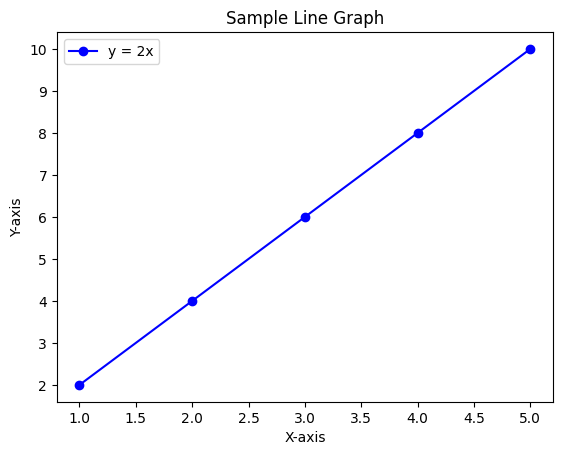

In [ ]:
# your sample input of graph
import matplotlib.pyplot as plt

# Sample data
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

# Create the plot
plt.plot(x, y, marker='o', linestyle='-', color='b', label='y = 2x')

# Add title and labels
plt.title("Sample Line Graph")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

# Show legend
plt.legend()

# Display the graph
plt.show()

In [ ]:
#run prims algorithm for sample input
import heapq

# Function to implement Prim's Algorithm
def prim(graph, start=0):
    # Number of vertices in the graph
    num_vertices = len(graph)

    # To track the nodes already in MST
    mst_set = [False] * num_vertices

    # Priority queue (min-heap) to get the minimum weight edge
    min_heap = [(0, start)]  # (weight, vertex)

    total_weight = 0
    mst_edges = []

    while min_heap:
        weight, u = heapq.heappop(min_heap)

        # If vertex 'u' is already in MST, skip it
        if mst_set[u]:
            continue

        # Add this vertex to MST
        mst_set[u] = True
        total_weight += weight

        # For every adjacent vertex, if it's not in MST, add it to heap
        for v, w in enumerate(graph[u]):
            if not mst_set[v] and w != 0:
                heapq.heappush(min_heap, (w, v))
                if weight != 0:  # Skip adding for the initial node
                    mst_edges.append((u, v, w))

    return mst_edges, total_weight

# Sample graph input (Adjacency Matrix)
graph = [
    [0, 2, 0, 6, 0],
    [2, 0, 3, 8, 5],
    [0, 3, 0, 0, 7],
    [6, 8, 0, 0, 9],
    [0, 5, 7, 9, 0]
]

# Running Prim's algorithm starting from vertex 0
mst_edges, total_weight = prim(graph)

print("Minimum Spanning Tree Edges:")
for u, v, w in mst_edges:
    print(f"{u} - {v}: {w}")

print(f"Total weight of MST: {total_weight}")

Minimum Spanning Tree Edges:
1 - 2: 3
1 - 3: 8
1 - 4: 5
2 - 4: 7
4 - 3: 9
Total weight of MST: 16


Use same apporach for Kruskal's algorithm

In [ ]:
# implement Kruskal's algorithm
# Union-Find (Disjoint Set) Data Structure to help detect cycles
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, u):
        if self.parent[u] != u:
            self.parent[u] = self.find(self.parent[u])  # Path compression
        return self.parent[u]

    def union(self, u, v):
        root_u = self.find(u)
        root_v = self.find(v)

        # Union by rank
        if root_u != root_v:
            if self.rank[root_u] > self.rank[root_v]:
                self.parent[root_v] = root_u
            elif self.rank[root_u] < self.rank[root_v]:
                self.parent[root_u] = root_v
            else:
                self.parent[root_v] = root_u
                self.rank[root_u] += 1
            return True
        return False

# Kruskal's Algorithm Implementation
def kruskal(graph, num_vertices):
    # List to store the MST edges
    mst_edges = []
    total_weight = 0

    # Convert the graph into a list of edges (u, v, weight)
    edges = []
    for u in range(num_vertices):
        for v in range(u + 1, num_vertices):  # Only take one direction of edges (since undirected)
            if graph[u][v] != 0:  # If there's an edge
                edges.append((graph[u][v], u, v))

    # Sort edges based on weight
    edges.sort()

    # Create Union-Find data structure
    uf = UnionFind(num_vertices)

    # Iterate through sorted edges and add them to MST if they don't form a cycle
    for weight, u, v in edges:
        if uf.union(u, v):  # If adding this edge doesn't form a cycle
            mst_edges.append((u, v, weight))
            total_weight += weight

    return mst_edges, total_weight

# Sample graph input (Adjacency Matrix)
graph = [
    [0, 2, 0, 6, 0],
    [2, 0, 3, 8, 5],
    [0, 3, 0, 0, 7],
    [6, 8, 0, 0, 9],
    [0, 5, 7, 9, 0]
]

# Running Kruskal's algorithm
mst_edges, total_weight = kruskal(graph, len(graph))

print("Minimum Spanning Tree Edges:")
for u, v, w in mst_edges:
    print(f"{u} - {v}: {w}")

print(f"Total weight of MST: {total_weight}")

Minimum Spanning Tree Edges:
0 - 1: 2
1 - 2: 3
1 - 4: 5
0 - 3: 6
Total weight of MST: 16
